## 1.Import Necessary Libraries

In [2]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## 2.Load Datasets

In [3]:
wine_data=load_wine()
wine_data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
wine_data_df=pd.DataFrame(data=wine_data.data,columns=wine_data.feature_names)
wine_data_df["Target"]=wine_data.target
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


## 3.Data_Understanding

In [5]:
wine_data_df.shape

(178, 14)

In [6]:
wine_data_df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [7]:
wine_data_df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Target                            int64
dtype: object

## 4.Model Building

In [8]:
wine_data_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [9]:
x=wine_data_df.drop("Target",axis=1)
y=wine_data_df["Target"]

In [10]:
x

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [11]:
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: Target, Length: 178, dtype: int64

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=11,shuffle=True,stratify=y)

In [13]:
x_train.shape,y_train.shape

((142, 13), (142,))

In [14]:
x_test.shape,y_test.shape

((36, 13), (36,))

## 5.Model Training || Model Testing || Model Evaluation

### when k=3

In [15]:
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.8592


## when k= 5

In [16]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.7676


### when k=7

In [17]:
knn_model=KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.7606


### when k=9

In [18]:
knn_model=KNeighborsClassifier(n_neighbors=9)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.7887


## Lets apply Standardisation Technique

In [19]:
std_scaler=StandardScaler()
scaled_x=std_scaler.fit_transform(x)
scaled_x
x_train,x_test,y_train,y_test=train_test_split(scaled_x,y,test_size=0.20,random_state=11,shuffle=True,stratify=y)


## whn k= 3

In [20]:
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9718


## when k= 5

In [21]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9789


### when k=7

In [22]:
knn_model=KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9789


### when k=9

In [23]:
knn_model=KNeighborsClassifier(n_neighbors=9)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9648


## How to chose optimal no of neighbours?

In [24]:
from sklearn.model_selection import KFold,cross_val_score

In [44]:
kfold=KFold(n_splits=5,shuffle=True,random_state=123)
cv_scores_mean=[]

for i in range(3,51,2):
    knn_classifier=KNeighborsClassifier(n_neighbors=i)
    knn_classifier.fit(scaled_x,y)
    cv_scores=cross_val_score(estimator=knn_classifier,X=scaled_x,y=y,cv=kfold)
    cv_scores_mean.append(cv_scores.mean().round(4))

In [36]:
max(cv_scores_mean)

np.float64(0.9773)

In [37]:
cv_scores_mean.index(max(cv_scores_mean))

10

## Let's Visualize

In [39]:
from matplotlib import pyplot as plt

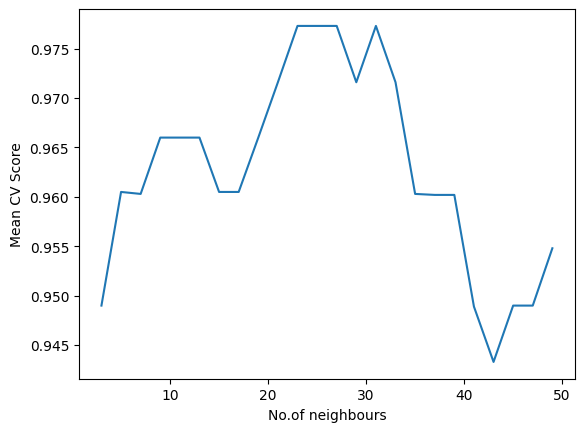

In [42]:
plt.plot(range(3,51,2),cv_scores_mean)
plt.xlabel("No.of neighbours")
plt.ylabel("Mean CV Score")
plt.show()

In [43]:
knn_model=KNeighborsClassifier(n_neighbors=23)
knn_model.fit(x_train,y_train)
y_pred_train=knn_model.predict(x_train)

print("Training Accuracy:",round(accuracy_score(y_train,y_pred_train),4))

Training Accuracy: 0.9789
